In [1]:
from pathlib import Path

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

%cd {project_root}

/home/ubuntu/Desktop/world_models_project/psi0_workspace/Psi0


/home/ubuntu/Desktop/world_models_project/psi0_workspace/Psi0/.venv-psi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
import torch
import numpy as np
from pathlib import Path
from psi.utils import parse_args_to_tyro_config, seed_everything, move_to_device, batchify
from psi.config.config import LaunchConfig
import os

PSI_HOME = os.environ["PSI_HOME"] = "/home/ubuntu/Desktop/world_models_project/psi0_workspace"

In [ ]:
ckpt_step = 40000
# run_dir = Path(".runs/finetune/g1wholebodybendpick-v1.simple.flow1000.cosine.lr1.0e-04.b128.gpus8.2603210854")
run_dir = Path("/home/ubuntu/Desktop/world_models_project/psi0_workspace/training_output/finetune/open_a_drawer_g1.real.flow1000.cosine.lr1.0e-04.b128.gpus8.2605062254")
config_:LaunchConfig = parse_args_to_tyro_config(run_dir / "argv.txt") # type: ignore
conf = (run_dir / "run_config.json").open("r").read()
launch_config = config_.model_validate_json(conf)

In [4]:
seed_everything(launch_config.seed or 42)
print("launch_config.seed:", launch_config.seed)

launch_config.seed: 292285


In [5]:
device = "cuda:0"

In [6]:
from psi.models.psi0 import Psi0Model 
psi0 = Psi0Model.from_pretrained(run_dir, ckpt_step, launch_config, device=device)
psi0.to(device)
psi0.eval()
print("Model loaded successfully.")

You are attempting to use Flash Attention 2 without specifying a torch dtype. This might lead to unexpected behaviour
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


[17:23:54 05/13] INFO     | >> [*] Resized model token embeddings to 153792                            ]8;id=3275645;file:///home/ubuntu/Desktop/world_models_project/psi0_workspace/Psi0/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=3275646;file:///home/ubuntu/Desktop/world_models_project/psi0_workspace/Psi0/src/psi/models/psi0.py#1550\1550]8;;\

                 INFO     | >> [*] loaded vlm_backbone checkpoint successfully.                        ]8;id=3275652;file:///home/ubuntu/Desktop/world_models_project/psi0_workspace/Psi0/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=3275653;file:///home/ubuntu/Desktop/world_models_project/psi0_workspace/Psi0/src/psi/models/psi0.py#1553\1553]8;;\

[17:23:57 05/13] INFO     | >> [*] Total ActionTransformerModel parameters: 497,719,256                ]8;id=3275659;file:///home/ubuntu/Desktop/world_models_project/psi0_workspace/Psi0/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=3275660;file:///home/ubuntu/Desktop/world_models_project/psi0_workspace/Psi0/src/psi/models/psi0.py#1510\1510]8;;\

                 INFO     | >> [*] Total VLM Backbone parameters: 2,131,333,120                        ]8;id=3275666;file:///home/ubuntu/Desktop/world_models_project/psi0_workspace/Psi0/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=3275667;file:///home/ubuntu/Desktop/world_models_project/psi0_workspace/Psi0/src/psi/models/psi0.py#1514\1514]8;;\

                 INFO     | >> [*] loaded action head checkpoint successfully.                         ]8;id=3275673;file:///home/ubuntu/Desktop/world_models_project/psi0_workspace/Psi0/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=3275674;file:///home/ubuntu/Desktop/world_models_project/psi0_workspace/Psi0/src/psi/models/psi0.py#1571\1571]8;;\

Model loaded successfully.


In [7]:
from psi.config.data_lerobot import LerobotDataConfig
data_cfg: LerobotDataConfig = launch_config.data # type: ignore

from psi.config.model_psi0 import Psi0ModelConfig
model_cfg: Psi0ModelConfig = launch_config.model # type: ignore

In [8]:
maxmin = data_cfg.transform.field

In [9]:
transform_kwargs=dict(
    vlm_processor=psi0.vlm_processor,
)

In [ ]:
launch_config.data
transform_kwargs
import os
# PSI_HOME = os.environ["PSI_HOME"] = "/home/ubuntu/Desktop/world_models_project/psi0_workspace"
os.environ

environ{'USER': 'ubuntu',
        'SSH_CLIENT': '10.102.4.154 50758 22',
        'XDG_SESSION_TYPE': 'tty',
        'SHLVL': '0',
        'LD_LIBRARY_PATH': '/opt/amazon/openmpi/lib:/usr/local/lib:/usr/lib:/opt/amazon/openmpi/lib:/usr/local/lib:/usr/lib:/opt/amazon/openmpi/lib:/usr/local/lib:/usr/lib',
        'HOME': '/home/ubuntu',
        'SSL_CERT_FILE': '/usr/lib/ssl/cert.pem',
        'DBUS_SESSION_BUS_ADDRESS': 'unix:path=/run/user/1000/bus',
        'LOGNAME': 'ubuntu',
        '_': '/home/ubuntu/Desktop/world_models_project/psi0_workspace/Psi0/.venv-psi/bin/python',
        'XDG_SESSION_CLASS': 'user',
        'XDG_SESSION_ID': '18085',
        'VSCODE_CLI_REQUIRE_TOKEN': 'ec38aa58-29a2-49e1-b3aa-d35aea3290f2',
        'PATH': '/home/ubuntu/Desktop/world_models_project/psi0_workspace/Psi0/.venv-psi/bin:/home/ubuntu/.vscode-server/cli/servers/Stable-072586267e68ece9a47aa43f8c108e0dcbf44622/server/bin/remote-cli:/home/ubuntu/.local/bin:/home/ubuntu/google-cloud-sdk/bin:/home/ubu

In [17]:
dataset = data_cfg(split="train", transform_kwargs=transform_kwargs)

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [19]:
dataset.raw_dataset.meta

LeRobotDatasetMetadata({
    Repository ID: 'open_a_drawer_g1',
    Total episodes: '40',
    Total frames: '15728',
    Features: '['observation.images.egocentric', 'states', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'next.done', 'task_index']',
})',

In [20]:
eps_idx = np.random.randint(0, dataset.raw_dataset.meta.total_episodes)
print(eps_idx)

24


In [24]:
start_frame_idx = dataset.raw_dataset.base_dataset.episode_data_index["from"][eps_idx].item()
end_frame_idx = dataset.raw_dataset.base_dataset.episode_data_index["to"][eps_idx].item()

print(f"start_frame_idx:", start_frame_idx, " end_frame_idx:", end_frame_idx)
print("num frames in this episode:", end_frame_idx - start_frame_idx)

start_frame_idx: 9913  end_frame_idx: 10299
num frames in this episode: 386


In [33]:
avg_action_errors_denormed_list = []

labels_denormed = [
    "hand_joints",
    "arm_joints",
    "torsor_roll", # torso rpy
    "torsor_pitch", # torso rpy
    "torsor_yaw", # torso rpy
    "height",
    "vx",
    "vy",
    "torso_vyaw",
    "target_yaw",
]

stride = 4
for i in range(start_frame_idx, end_frame_idx, stride):
    frame = dataset[i]
    # print(list(frame.keys()))
    images = frame["raw_images"]
    batch_images = [images] # List[List[PIL.Image.Image]] batch size == 1
    instruction = frame['instruction']
    batch_instructions = [instruction] # List[str]

    states = frame['states'] # (H, D)
    # print("states.shape:", states.shape)
    states = np.zeros_like(states) ###===###
    batch_states = torch.from_numpy(states).unsqueeze(0).to(device) # (B, H, D)

    pred_actions = psi0.predict_action(
        observations=batch_images, 
        states=batch_states, 
        instructions=batch_instructions, 
        num_inference_steps=10, 
        traj2ds=None
    )

    print(f"\npred_actions[..., 0, -8:]:", pred_actions[..., 0, -8:])
    print(f"pred_actions.shape:", pred_actions.shape)
    
    gt_action = torch.from_numpy(frame["raw_actions"]).unsqueeze(0).to(device) # (1, Tp, Da)
    denormalized_pred_actions = maxmin.denormalize(pred_actions)
    print(f"gt_action[..., 0, -8:]:", gt_action[..., 0, -8:])
    print(f"denormalized_pred_actions[..., 0, -8:]:", denormalized_pred_actions[..., 0, -8:])

    error = denormalized_pred_actions - gt_action # (1, Tp, Da)
    error_l1 = error.detach().abs().cpu().numpy().reshape(-1, gt_action.shape[-1]) # (Tp, Da)

    avg_action_errors_denormed = error_l1.mean(0)
    avg_action_errors_denormed_list.append(avg_action_errors_denormed)

    # break

avg_action_errors_denormed_list = np.stack(avg_action_errors_denormed_list, axis=0)
avg_action_errors_denormed = avg_action_errors_denormed_list.mean(axis=0)

avg_action_errors_denormed_split = np.split(
    avg_action_errors_denormed, [14, 28, 31, 32, 33, 34, 35], axis=-1
)

print("\n---------------------------\n")
for i in range(len(avg_action_errors_denormed_split)):
    print(f"denormed_err_l1_{labels_denormed[i]} {avg_action_errors_denormed_split[i].shape}:  {np.linalg.norm(avg_action_errors_denormed_split[i])}")



pred_actions[..., 0, -8:]: tensor([[ 6.3324e-04,  3.8147e-03,  5.2452e-05, -3.8300e-03, -2.3651e-03,
         -1.4648e-03, -2.5940e-03,  5.3406e-03]], device='cuda:0')
pred_actions.shape: torch.Size([1, 30, 36])
gt_action[..., 0, -8:]: tensor([[0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0')
denormalized_pred_actions[..., 0, -8:]: tensor([[0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0')

pred_actions[..., 0, -8:]: tensor([[ 0.0005, -0.0003,  0.0034,  0.0038, -0.0006, -0.0044, -0.0025,  0.0042]],
       device='cuda:0')
pred_actions.shape: torch.Size([1, 30, 36])
gt_action[..., 0, -8:]: tensor([[0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0')
denormalized_pred_actions[..., 0, -8:]: tensor([[0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0')

pred_actions[..., 0, -8:]: tensor([[-0.0019,  0.0024,  0.0044, -0.0014, -0.0012,  0.0004,  0.0017,  0.0003]],
       device='cuda:0')
pred_actions.shape: torch.Size([1, 30, 36])
gt_action[..., 0, -8:]: tensor([[0., 0., 0., 0., 0., 0., 0., 

KeyboardInterrupt: 

In [26]:
!uv pip install matplotlib

Using Python 3.10.19 environment at: .venv-psi
Resolved 11 packages in 187ms                                        
⠙ Preparing packages... (0/4)                                                   
⠙ Preparing packages... (0/4)-------------------     0 B/4.67 MiB            
⠙ Preparing packages... (0/4)------------------- 14.87 KiB/4.67 MiB          
⠙ Preparing packages... (0/4)------------------- 14.87 KiB/4.67 MiB          
fonttools            ------------------------------ 14.87 KiB/4.67 MiB
⠙ Preparing packages... (0/4)-------------------     0 B/8.36 MiB            
fonttools            ------------------------------ 14.87 KiB/4.67 MiB
⠙ Preparing packages... (0/4)------------------- 14.86 KiB/8.36 MiB          
fonttools            ------------------------------ 14.87 KiB/4.67 MiB
⠙ Preparing packages... (0/4)------------------- 14.86 KiB/8.36 MiB          
fonttools            ------------------------------ 14.87 KiB/4.67 MiB
⠙ Preparing packages... (0/4)------------------- 1

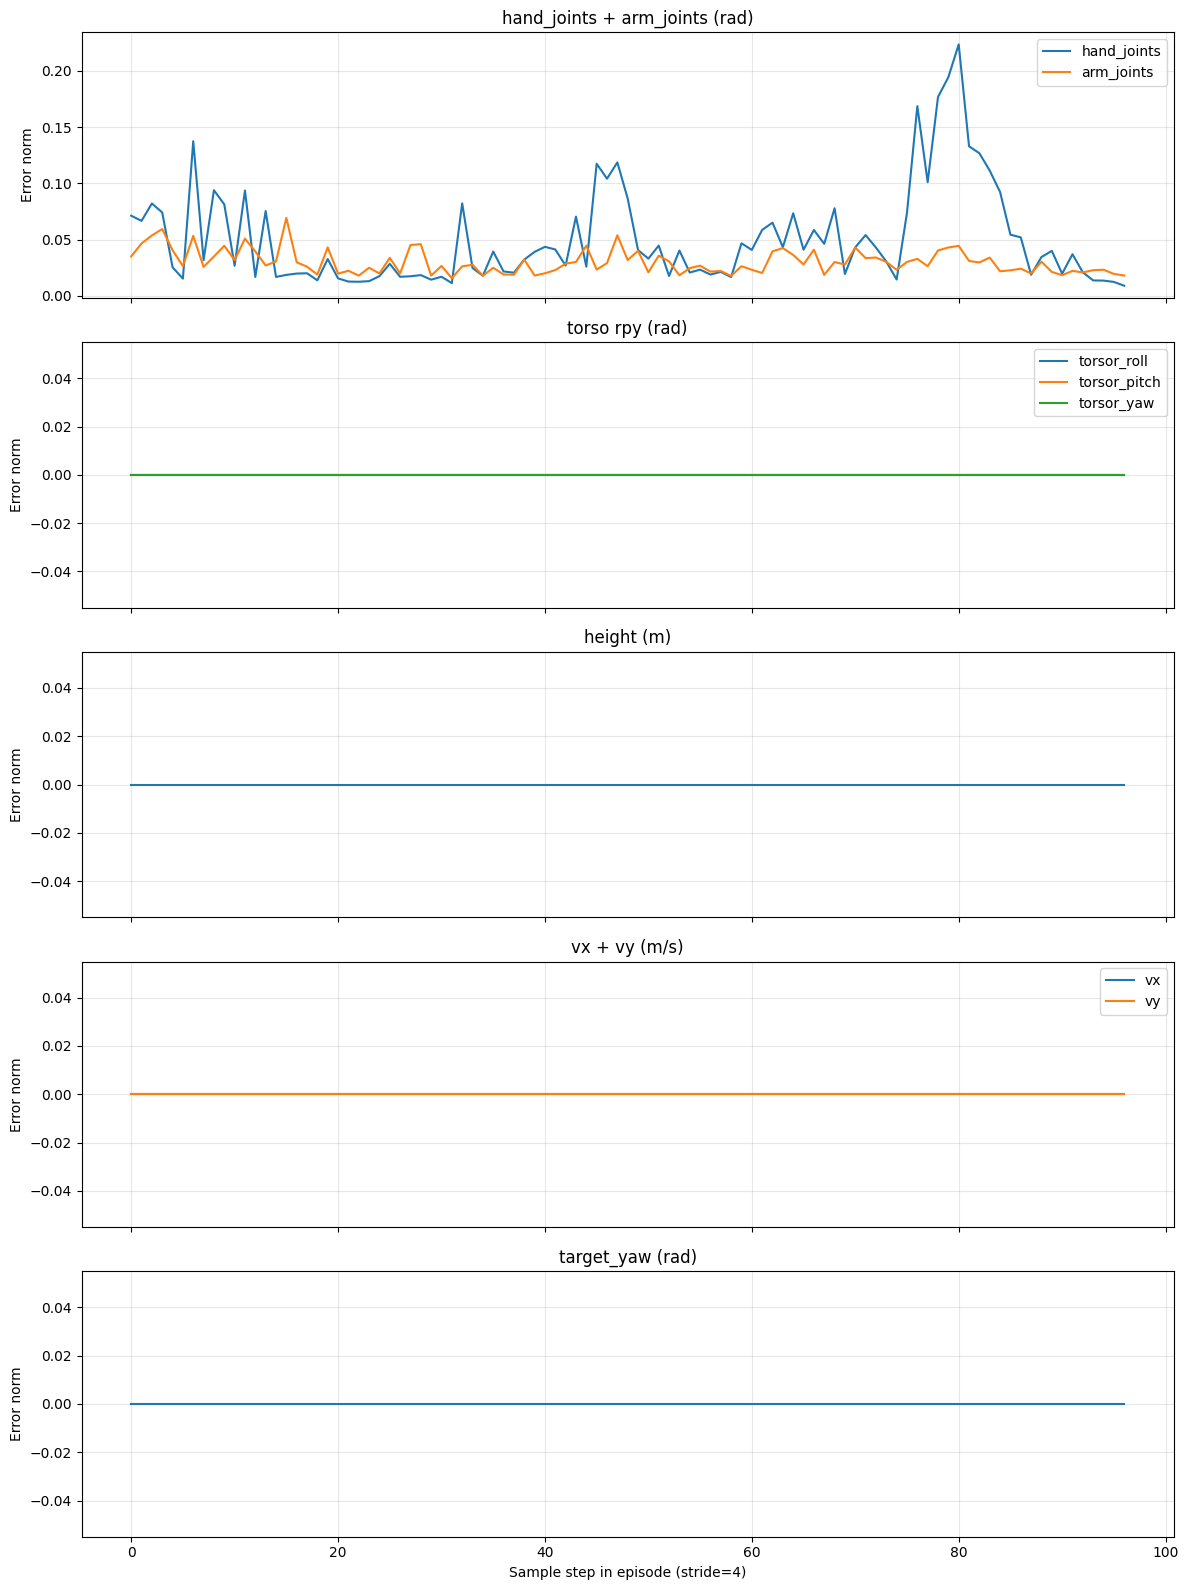

In [27]:
import matplotlib.pyplot as plt

# avg_action_errors_denormed_list: (T, 36)
group_slices = [14, 28, 29, 30, 31, 32, 33, 34, 35]
error_groups = np.split(avg_action_errors_denormed_list, group_slices, axis=-1)

# One scalar curve per semantic group
per_label_curves = [np.linalg.norm(group, axis=-1) for group in error_groups]
curve_map = dict(zip(labels_denormed, per_label_curves))

# Use target_dyaw as target_yaw for plotting name consistency
curve_map["target_yaw"] = curve_map.get("target_yaw", curve_map.get("target_dyaw"))

plot_groups = [
    ("hand_joints + arm_joints (rad)", ["hand_joints", "arm_joints"]),
    ("torso rpy (rad)", ["torsor_roll", "torsor_pitch", "torsor_yaw"]), # plot rpy separately
    ("height (m)", ["height"]),
    ("vx + vy (m/s)", ["vx", "vy"]),
    ("target_yaw (rad)", ["target_yaw"]),
]

fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)

for ax, (title, keys) in zip(axes, plot_groups):
    for key in keys:
        curve = curve_map.get(key)
        if curve is None:
            continue
        ax.plot(curve, label=key)
    ax.set_title(title)
    ax.set_ylabel("Error norm")
    ax.grid(True, alpha=0.3)
    if len(keys) > 1:
        ax.legend()

axes[-1].set_xlabel("Sample step in episode (stride=4)")
plt.tight_layout()
plt.show()